In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("amz_uk_price_prediction_dataset.csv")
display(df.shape)
df.info()
df.head(20)

(2443651, 9)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               object 
 2   title              object 
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           object 
dtypes: bool(1), float64(2), int64(3), object(3)
memory usage: 151.5+ MB


,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers
5,6,B09B97WSLF,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
6,7,B09B9615X2,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
7,8,B01MTB55WH,Anker Soundcore 2 Portable Bluetooth Speaker w...,4.7,103673,39.99,False,0,Hi-Fi Speakers
8,9,B016MO90GW,"Bluetooth Speaker, Anker Soundcore Speaker Upg...",4.7,29909,29.99,False,0,Hi-Fi Speakers
9,10,B09ZQF5GZW,RIENOK Bluetooth Speaker Portable Wireless Blu...,4.5,16014,29.99,False,0,Hi-Fi Speakers


### Part 1: Analyzing Best-Seller Trends Across Product Categories

1. **Crosstab Analysis**:
    - Create a crosstab between the product `category` and the `isBestSeller` status.
    
    - Are there categories where being a best-seller is more prevalent? 
    	
    	*Hint: one option is to calculate the proportion of best-sellers for each category and then sort the categories based on this proportion in descending order.*

In [3]:
crosstab = pd.crosstab(index=df["category"], columns=df["isBestSeller"])
display(crosstab)

isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3
...,...,...
Wind Instruments,243,7
Window Treatments,234,5
Women,17559,213


In [4]:
category_proportions = df.groupby("category")["isBestSeller"].mean().sort_values(ascending=False)
df_best_sellers_report = category_proportions.reset_index()
df_best_sellers_report.columns = ["Category", "Best_Seller_Proportion"]
display(df_best_sellers_report)

,Category,Best_Seller_Proportion
0,Grocery,0.058135
1,Smart Home Security & Lighting,0.057692
2,Health & Personal Care,0.057686
3,Mobile Phone Accessories,0.042471
4,Power & Hand Tools,0.035339
...,...,...
291,"CD, Disc & Tape Players",0.000000
292,General Music-Making Accessories,0.000000
293,Snowboard Boots,0.000000
294,Boxes & Organisers,0.000000


C:\Users\fotos\AppData\Local\Temp\ipykernel_5868\3146728778.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


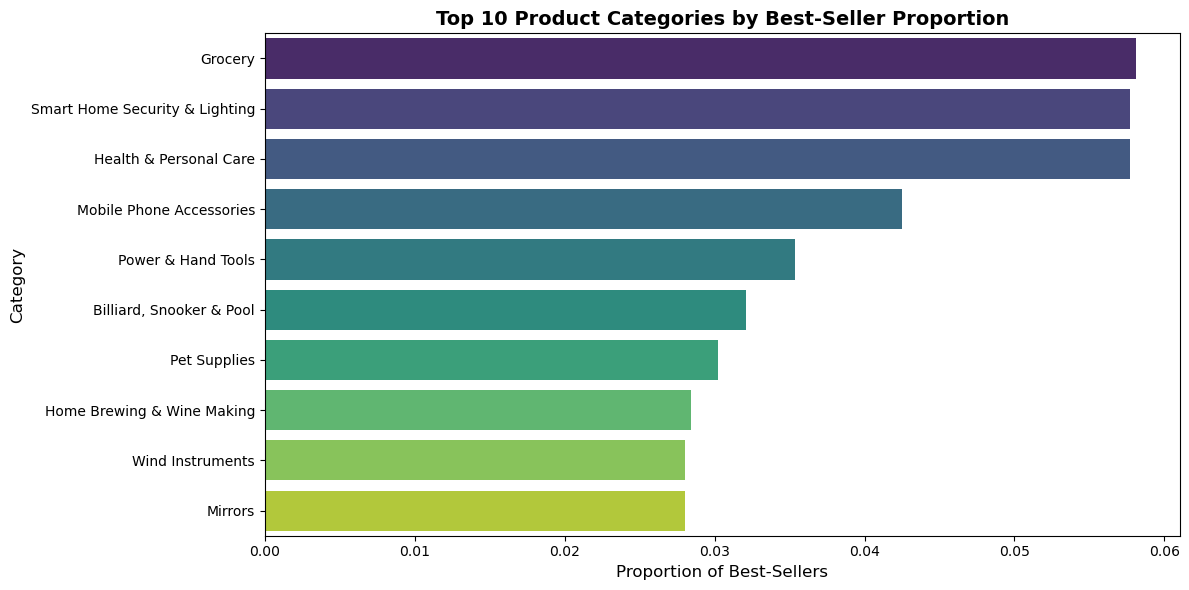

In [5]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_best_sellers_report.head(10),
    x="Best_Seller_Proportion",
    y="Category",
    palette="viridis",
)

plt.title(
    "Top 10 Product Categories by Best-Seller Proportion",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Proportion of Best-Sellers", fontsize=12)
plt.ylabel("Category", fontsize=12)

plt.tight_layout()
plt.show()

2. **Statistical Tests**:
    - Conduct a Chi-square test to determine if the best-seller distribution is independent of the product category.
    - Compute Cramér's V to understand the strength of association between best-seller status and category.

In [6]:
import numpy as np
from scipy.stats import chi2_contingency

In [7]:
chi2_statistic, chi2_p_value, dof, expected_freq = chi2_contingency(crosstab)
print(f"chi2: {chi2_statistic:.4f}")
print(f"P-value: {chi2_p_value}")
print(f"dof: {dof}")

chi2: 36540.2027
P-value: 0.0
dof: 295


In [8]:
alfa = 0.05
if chi2_p_value < alfa:
    print("we reject the H0.")
    print("CONCLUSION: yes, they are related. Best sellers distribution is NOT independent of the product category.")
else:
    print("we cant reject the H0.")
    print("CONCLUSION:the best-seller distribution is independent of the product category.")


we reject the H0.
CONCLUSION: yes, they are related. Best sellers distribution is NOT independent of the product category.


3. **Visualizations**:
	- Visualize the relationship between product categories and the best-seller status using a stacked bar chart.

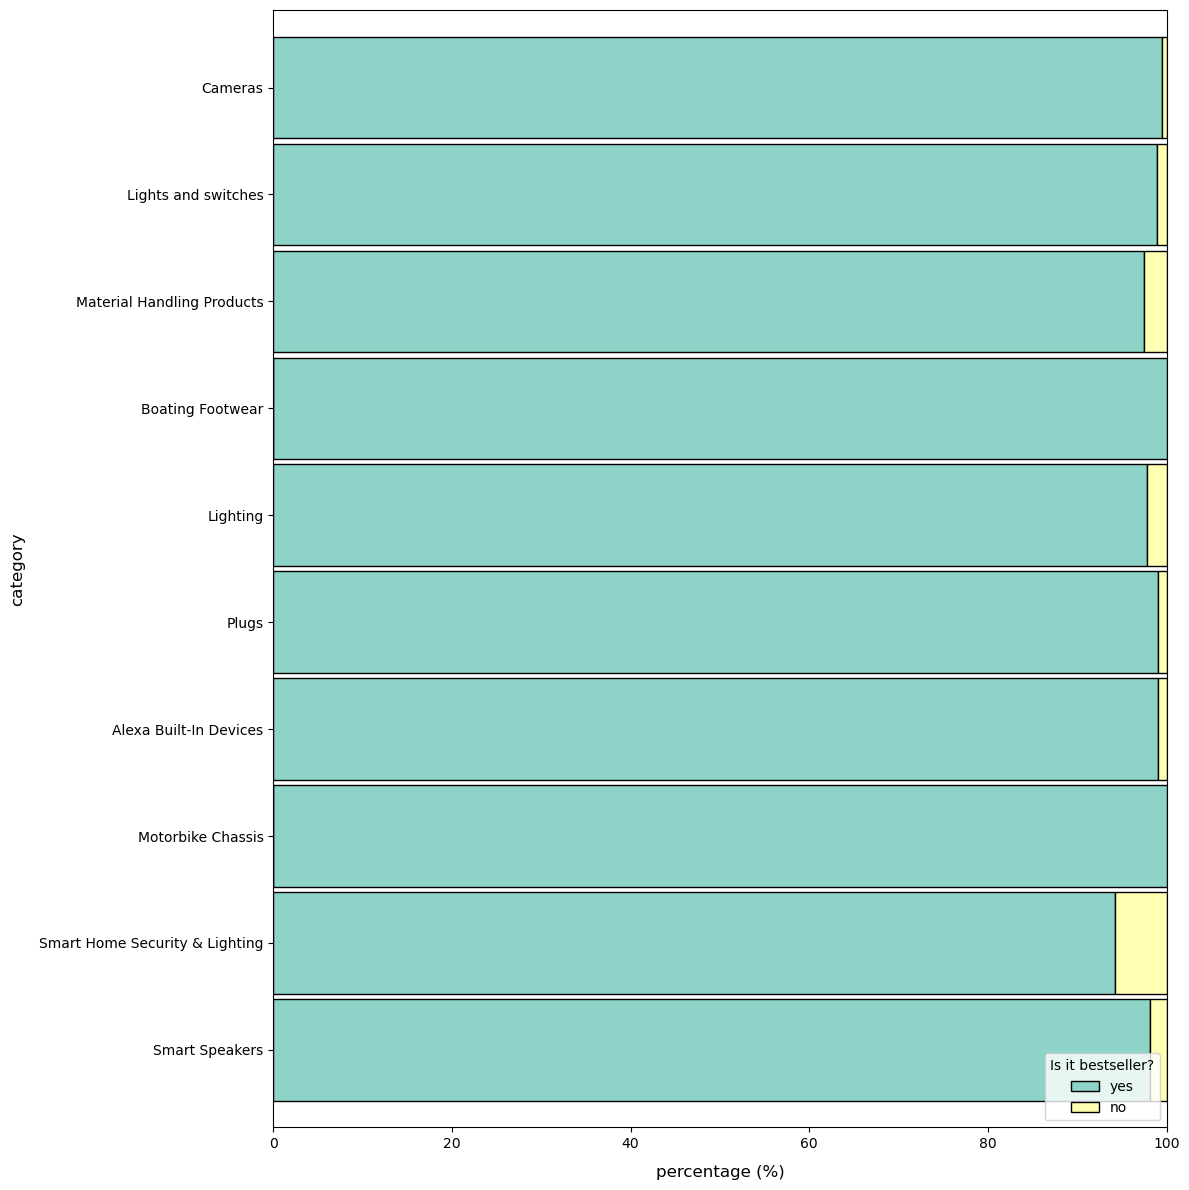

In [9]:
top_10_crosstab = crosstab.loc[crosstab.sum(axis=1).sort_values(ascending=True).head(10).index]
percentaje_table = top_10_crosstab.div(top_10_crosstab.sum(axis=1), axis=0) * 100

ax_prop = percentaje_table.plot(
    kind='barh', 
    stacked=True, 
    color=plt.cm.Set3.colors[:5], 
    edgecolor='black',
    figsize=(12, 12), 
    width=0.95
)

plt.xlabel('percentage (%)', fontsize=12, labelpad=10)
plt.ylabel('category', fontsize=12, labelpad=10)
plt.xlim(0, 100)
plt.legend(title='Is it bestseller?', labels=['yes', 'no'], loc='lower right')

for p in ax_prop.patches:
    width = p.get_width()    
    height = p.get_height()  
    x, y = p.get_xy()
    

plt.tight_layout()
plt.savefig('bestseller_stacked_percentage_fixed.png', bbox_inches='tight')
plt.show()

### Part 2: Exploring Product Prices and Ratings Across Categories and Brands

0. **Preliminary Step: Remove outliers in product prices.**

	For this purpose, we can use the IQR (Interquartile Range) method. Products priced below the first quartile minus 1.5 times the IQR or above the third quartile plus 1.5 times the IQR will be considered outliers and removed from the dataset. The next steps will be done with the dataframe without outliers.

In [10]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
low_limit = Q1 - 1.5 * IQR
high_limit = Q3 + 1.5 * IQR

print(f"--- outlier's limits ---")
print(f"lower limit: {low_limit:.2f}")
print(f"higher limit: {high_limit:.2f}\n")

--- outlier's limits ---
lower limit: -44.01
higher limit: 99.99



In [11]:
outliers = df[(df['price'] < low_limit) | (df['price'] > high_limit)]
print(f"outliers being removed: {len(outliers)}")

outliers being removed: 327688


In [12]:
df_clean = df[(df['price'] >= low_limit) & (df['price'] <= high_limit)]

print(f"original df: {df.shape[0]}")
print(f"cleaned df: {df_clean.shape[0]}")

original df: 2443651
cleaned df: 2115963


1. **Violin Plots**:
    - Use a violin plot to visualize the distribution of `price` across different product `categories`. Filter out the top 20 categories based on count for better visualization.
    - Which product category tends to have the highest median price? Don't filter here by top categories.

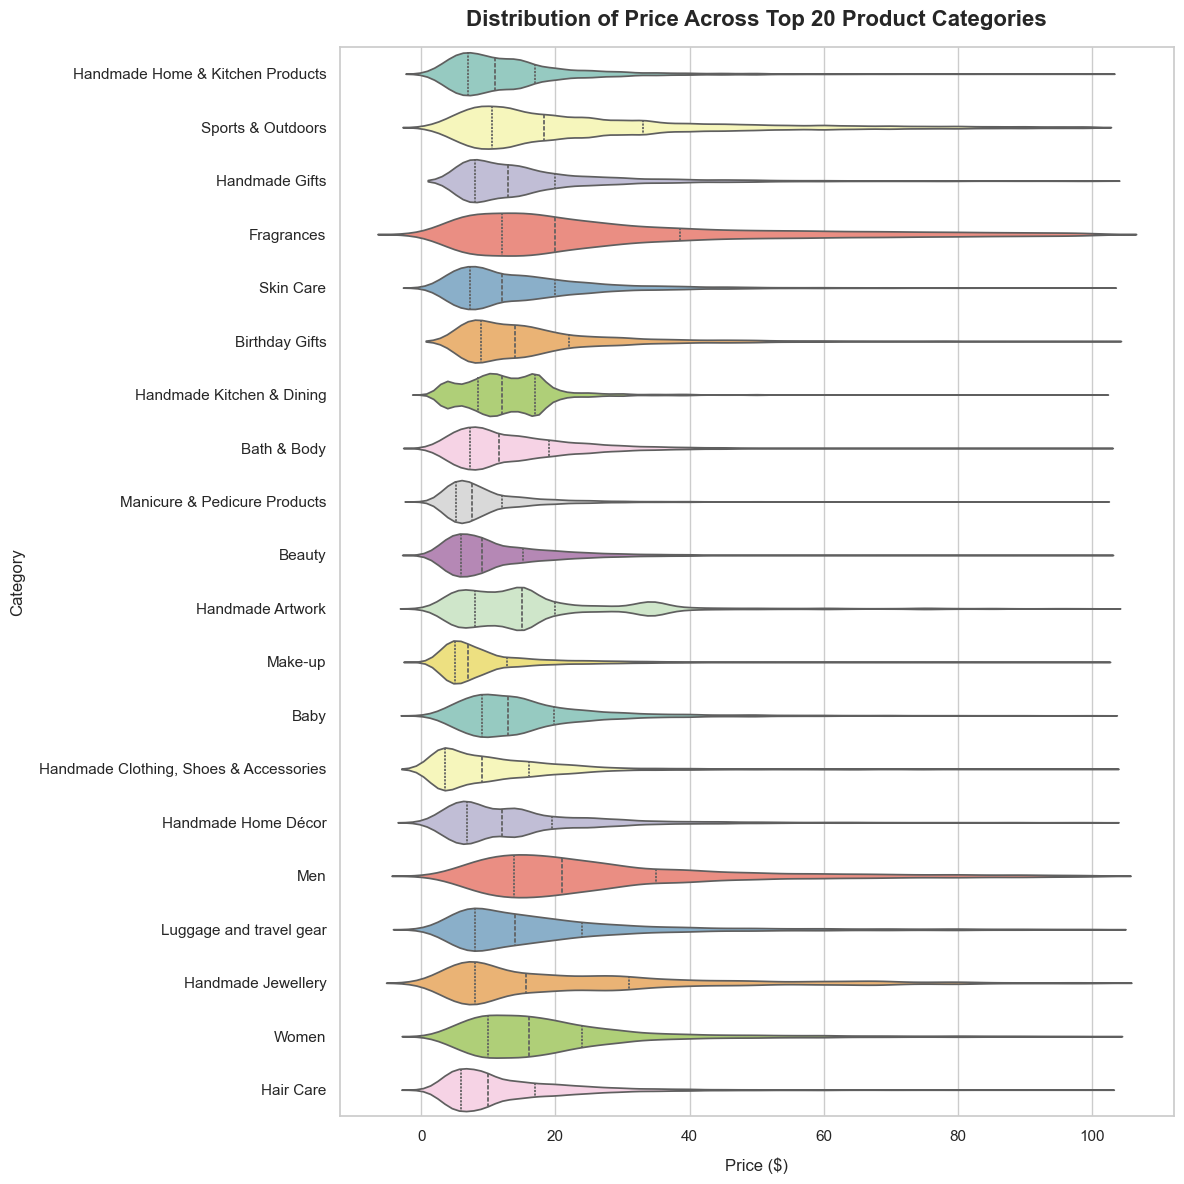

In [13]:
top_20_cat = df_clean['category'].value_counts().nlargest(20).index
df_top20 = df_clean[df_clean['category'].isin(top_20_cat)]


plt.figure(figsize=(12, 12))
sns.set_theme(style="whitegrid")

sns.violinplot(
    data=df_top20, 
    x='price', 
    y='category', 
    hue='category',
    palette='Set3', 
    legend=False,
    inner='quartile',     
)

plt.title('Distribution of Price Across Top 20 Product Categories', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Price ($)', fontsize=12, labelpad=10)
plt.ylabel('Category', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

In [14]:
higher_median_by_cat = df_clean.groupby('category')['price'].median().idxmax()
higher_median = df_clean.groupby('category')['price'].median().max()

print(f"The product category with the highest median price is: '{higher_median_by_cat}'")
print(f"Median price: ${higher_median:.2f}")


The product category with the highest median price is: 'Desktop PCs'
Median price: $74.00


2. **Bar Charts**:
    - Create a bar chart comparing the average price of products for the top 10 product categories (based on count).
    - Which product category commands the highest average price? Don't filter here by top categories.

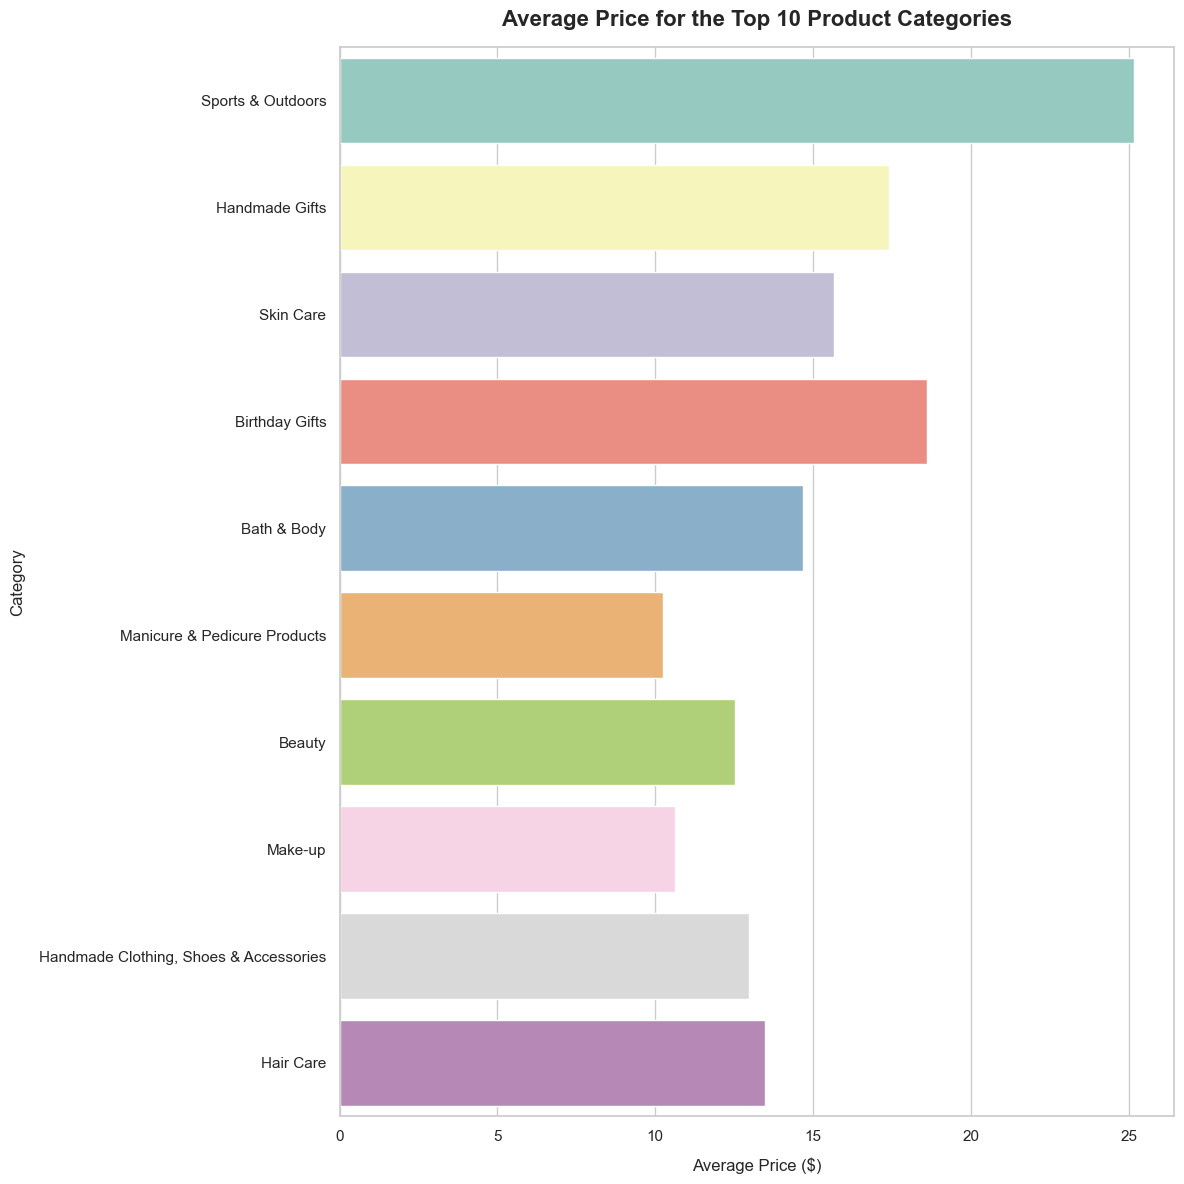

In [15]:
product_price_top10cat = df_clean['category'].value_counts().nlargest(10).index
df_avg_price = df_clean[df_clean['category'].isin(product_price_top10cat)]



plt.figure(figsize=(12, 12))
sns.set_theme(style="whitegrid")

sns.barplot(
    data=df_avg_price, 
    x='price', 
    y='category', 
    hue='category',
    palette='Set3', 
    legend=False, 
    errorbar=None
)

plt.title('Average Price for the Top 10 Product Categories', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Average Price ($)', fontsize=12, labelpad=10)
plt.ylabel('Category', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

In [16]:
mean_by_cat = df_clean.groupby('category')['price'].mean()

cat_highest_mean = mean_by_cat.idxmax()
max_mean_price = mean_by_cat.max()
print("--- Answer ---")
print(f"The product category with the highest average price is: '{cat_highest_mean}'")
print(f"Average price: ${max_mean_price:.2f}")

--- Answer ---
The product category with the highest average price is: 'Motherboards'
Average price: $68.77


3. **Box Plots**:
    - Visualize the distribution of product `ratings` based on their `category` using side-by-side box plots. Filter out the top 10 categories based on count for better visualization.
    - Which category tends to receive the highest median rating from customers? Don't filter here by top categories.

In [17]:
top_10_cat_rating = df_clean["category"].value_counts().nlargest(10).index
df_top_10_rating = df_clean[df_clean["category"].isin(top_10_cat_rating)]

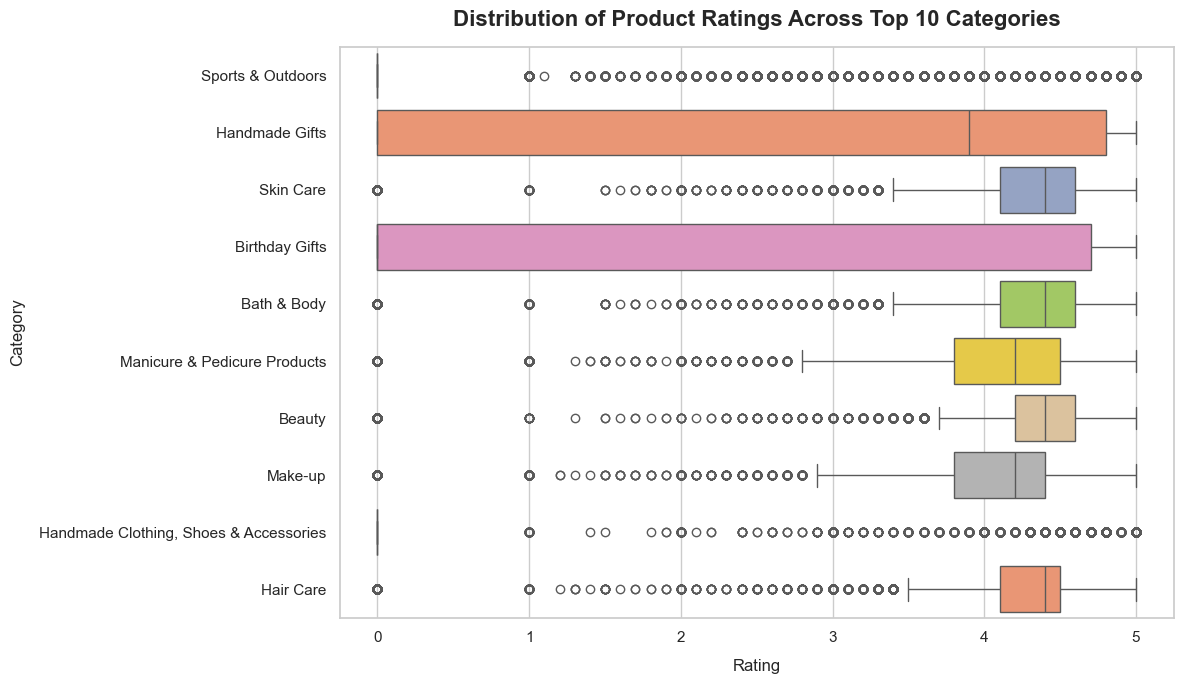

In [18]:
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

sns.boxplot(
    data=df_top_10_rating,
    x='stars',           
    y='category',         
    hue='category',       
    palette='Set2',      
    legend=False         
)

plt.title('Distribution of Product Ratings Across Top 10 Categories', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Rating', fontsize=12, labelpad=10)
plt.ylabel('Category', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

 ### Part 3: Investigating the Interplay Between Product Prices and Ratings       

1. **Correlation Coefficients**:
    - Calculate the correlation coefficient between `price` and `stars`.
    - Is there a significant correlation between product price and its rating?

In [19]:
correlation = df_clean['price'].corr(df_clean['stars'])

print("--- Correlation answer ---")
print(f"Pearson's correlation between price and rating is: {correlation:.4f}")



--- Correlation answer ---
Pearson's correlation between price and rating is: -0.0777


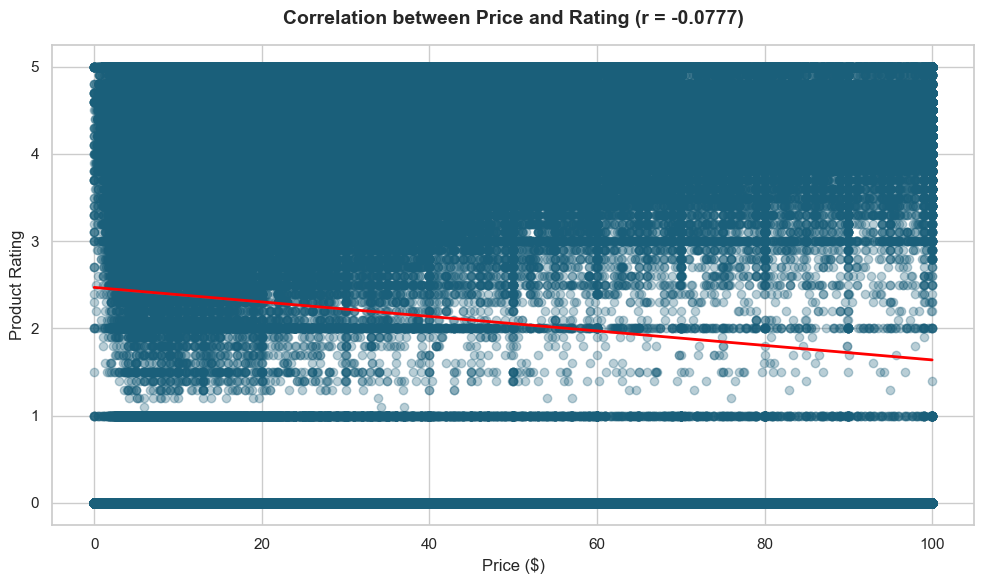

In [20]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.regplot(
    data=df_clean, 
    x='price', 
    y='stars', 
    scatter_kws={'alpha':0.3, 'color': '#1a5f7a'}, 
    line_kws={'color': 'red', 'linewidth': 2}      
)

plt.title(f"Correlation between Price and Rating (r = {correlation:.4f})", fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Price ($)', fontsize=12)
plt.ylabel('Product Rating', fontsize=12)

plt.tight_layout()
plt.show()

In [21]:
import scipy.stats as stats

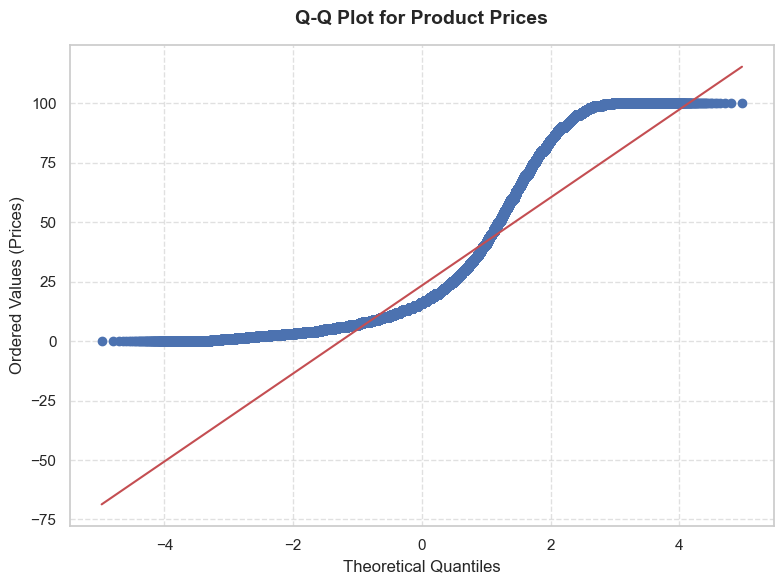

In [22]:
plt.figure(figsize=(8, 6))


stats.probplot(df_clean['price'], dist="norm", plot=plt)

plt.title('Q-Q Plot for Product Prices', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Theoretical Quantiles', fontsize=12)
plt.ylabel('Ordered Values (Prices)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Based on the Q-Q plot, the product prices do not follow a normal distribution. The points deviate significantly from the theoretical straight line, showing that the price data is skewed (non-normal).

**Bonus**: 

- Do the same analysis without taking out the outliers. What are your insights?

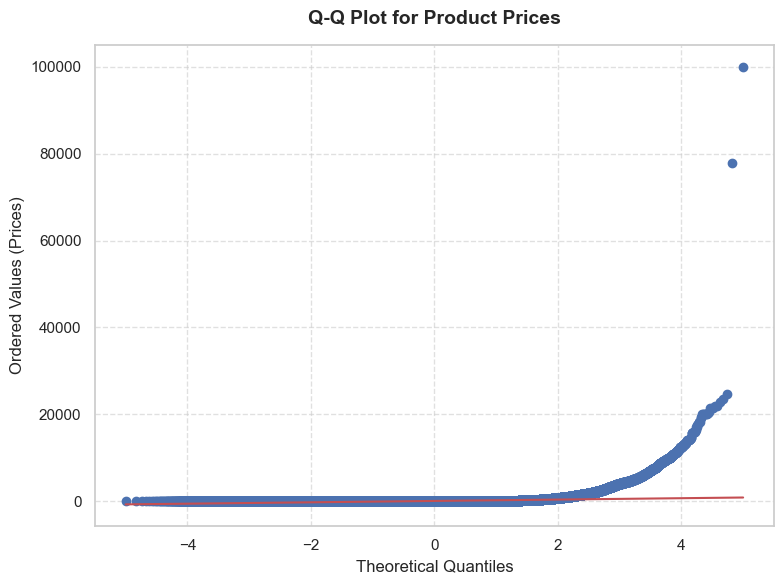

In [23]:
plt.figure(figsize=(8, 6))


stats.probplot(df['price'], dist="norm", plot=plt)

plt.title('Q-Q Plot for Product Prices', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Theoretical Quantiles', fontsize=12)
plt.ylabel('Ordered Values (Prices)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('prices_qq_plot.png', dpi=300)
plt.show()

"Based on the Q-Q plot, the product prices do not follow a normal distribution. While the lower and mid-range prices align with the theoretical quantiles, the upper tail deviates drastically upwards. This indicates that the price distribution is heavily skewed to the right with a severe long-tail effect caused by a small number of high-priced items."